## Missing values

In [1]:
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA = Path("../data")

df = pd.read_csv(DATA / 'ml_sessions_sensor_gaps.csv')

In [2]:
features = [
    'station_age_years', 'power_kw', 'num_bays', 'hour', 'day_of_week',
    'is_weekend', 'ambient_temp_c', 'grid_load_index', 'start_soc_pct',
    'battery_capacity_kwh']

X, y = df[features], df['failed']

print(X.isna().sum())

station_age_years          0
power_kw                   0
num_bays                   0
hour                       0
day_of_week                0
is_weekend                 0
ambient_temp_c          4437
grid_load_index         6260
start_soc_pct              0
battery_capacity_kwh       0
dtype: int64


In [3]:
df.shape

(45000, 17)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state=42, stratify = y
)

print(X_train.shape, X_test.shape)

(33750, 10) (11250, 10)


In [5]:
try:
    LogisticRegression().fit(X_train, y_train)
except Exception as e:
    print(type(e).__name__ + ":", e)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values


In [6]:
incomplete = X_train.isna().any(axis =1)

print(X_train[incomplete])

       station_age_years  power_kw  num_bays  hour  day_of_week  is_weekend  \
13400                7.0     120.0         7    18            6           1   
31730                7.0      30.0         4    10            5           1   
8690                 2.0     180.0         8    19            2           0   
3856                 7.0      30.0         2     1            1           0   
33594                5.0      30.0         1    22            1           0   
...                  ...       ...       ...   ...          ...         ...   
15809                4.0      60.0         3     9            3           0   
1759                 4.0      60.0         3    15            2           0   
3914                 3.0      30.0         2     8            6           1   
6445                 7.0     120.0         7    19            3           0   
15003                2.0      15.0         1    22            4           0   

       ambient_temp_c  grid_load_index  start_soc_p

In [7]:
print("training rows with atleast one gap: ", f"{incomplete.sum()}")

training rows with atleast one gap:  7535


In [8]:
print("failure in theese rows: ", y_train[incomplete].sum())

failure in theese rows:  829


In [9]:
y_train.value_counts()

failed
0    30899
1     2851
Name: count, dtype: int64

In [10]:
y_train[~incomplete].sum()

np.int64(2022)

In [11]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy= 'median')

imputer.fit(X_train)

fill = pd.Series(imputer.statistics_, index = features)
print(fill[['ambient_temp_c', 'grid_load_index']])

ambient_temp_c     29.800
grid_load_index     0.603
dtype: float64


In [12]:
df['ambient_temp_c'].isna().sum()

np.int64(4437)

In [13]:
df['grid_load_index'].median()

np.float64(0.603)

In [14]:
imputer.statistics_

array([ 4.   , 60.   ,  3.   , 13.   ,  3.   ,  0.   , 29.8  ,  0.603,
       40.   ,  8.5  ])

In [15]:
X_train_f = imputer.transform(X_train)
X_test_f = imputer.transform(X_test)

print("Gaps left in training dataset :", pd.DataFrame(X_train_f).isna().sum().sum())
print("gaps left in testing dataset :", pd.DataFrame(X_test_f).isna().sum().sum())

Gaps left in training dataset : 0
gaps left in testing dataset : 0


In [16]:
type(X_train_f)

numpy.ndarray

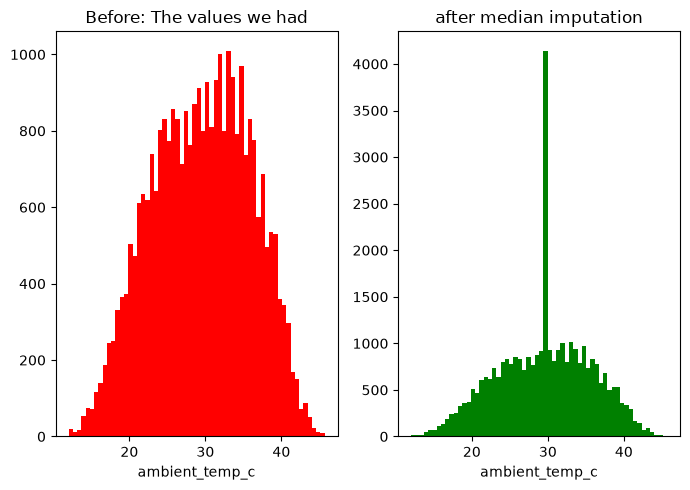

In [17]:
import matplotlib.pyplot as plt

col = features.index("ambient_temp_c")
fig, axes = plt.subplots(1, 2, figsize = (7,5), sharex = True)
axes[0].hist(X_train['ambient_temp_c'].dropna(), bins = 60, color = 'red')
axes[0].set_title("Before: The values we had")
axes[1].hist(X_train_f[:, col], bins = 60, color = 'green')
axes[1].set_title("after median imputation")

for a in axes:
    a.set_xlabel("ambient_temp_c")
plt.tight_layout()
plt.show()


In [18]:
df['ambient_temp_c'].isna().sum()

np.int64(4437)

In [19]:
df['ambient_temp_c'].min(), df['ambient_temp_c'].max()

(np.float64(12.0), np.float64(45.7))

In [20]:
scaler = StandardScaler().fit(X_train_f)
model = LogisticRegression().fit(scaler.transform(X_train_f), y_train)

median_auc = roc_auc_score(y_test, model.predict_proba(scaler.transform(X_test_f))[:,1])

print("ROC-auc on dataset with median imputation: ", round(median_auc, 4))

ROC-auc on dataset with median imputation:  0.6691


In [21]:
grid_missing = X_train['grid_load_index'].isna()

In [23]:
print(grid_missing.sum())

4673


In [27]:
print("failure rate when grid is missing :", round(y_train[grid_missing].mean(), 4))

failure rate when grid is missing : 0.1327


In [26]:
print("Failure rate when grid reading is present: ", round(y_train[~grid_missing].mean(), 3))

Failure rate when grid reading is present:  0.077


In [ ]:
imputer2 = SimpleImputer(strategy = 'median', add_indicator = True).fit(X_train)

print(imputer2.get_feature_names_out()[-3:])

['battery_capacity_kwh' 'missingindicator_ambient_temp_c'
 'missingindicator_grid_load_index']


In [31]:
X_train.isna().sum()

station_age_years          0
power_kw                   0
num_bays                   0
hour                       0
day_of_week                0
is_weekend                 0
ambient_temp_c          3343
grid_load_index         4673
start_soc_pct              0
battery_capacity_kwh       0
dtype: int64

In [32]:
A_train, A_test = imputer2.transform(X_train), imputer2.transform(X_test)

In [40]:
scaler2 = StandardScaler().fit(A_train)
model2 = LogisticRegression().fit(scaler2.transform(X_train), y_train)

new_auc = roc_auc_score(y_test, model2.predict_proba(scaler2.transform(A_test))[:, 1])
print("roc-auc, median + indicator: ", round(new_auc, 4))

c:\Users\AIML\miniconda3\envs\aiml\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


ValueError: X has 10 features, but StandardScaler is expecting 12 features as input.

In [37]:
model2.n_iter_

array([9], dtype=int32)

In [39]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train)
hgb_auc = roc_auc_score(y_test, hgb.predict_proba(X_test)[:, 1])
print("Hist gradient boosting classifier on raw dataset: ", round(hgb_auc, 4))

Hist gradient boosting classifier on raw dataset:  0.6776


## Exercises to try yourself:

1. Try strategy = 'constant' with fill_value = 0, 
and explain why fill_value = 0 is a bad choice for grid_load?

2. Compare the failure rate when ambient_temp_c is missing vs present, whether that difference is important just like the grid_load ? 

3. Rerun the indicator model with only the temperature indicator kept and check the auc ?